In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

X_train= np.load('../data/processed/X_train.npy')
X_val   = np.load('../data/processed/X_val.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')
snr_test = np.load('../data/processed/snr_test.npy')

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Using device: cuda
X_train: (154000, 2, 128), y_train: (154000,)
X_val:   (33000, 2, 128)
X_test:  (33000, 2, 128)


In [2]:
class RadioMLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = RadioMLDataset(X_train, y_train)
val_dataset   = RadioMLDataset(X_val, y_val)
test_dataset  = RadioMLDataset(X_test, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

sample_X, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_X.shape}")
print(f"Batch y shape: {sample_y.shape}")

Batch X shape: torch.Size([64, 2, 128])
Batch y shape: torch.Size([64])


In [4]:
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self,num_classes=11):
        super (CNN_BiLSTM_Attention, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=64,kernel_size=3,padding=1)
        self.bn1= nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        #Temporal modeling, bidirc
        self.lstm= nn.LSTM(input_size=64,hidden_size=64,num_layers=1,batch_first=True,bidirectional=True)
        #Attention
        self.attn_fc = nn.Linear(128,1)
        #Classifier
        self.dropout= nn.Dropout(0.5)
        self.fc1= nn.Linear(128,64)
        self.fc2= nn.Linear(64,num_classes)

    def attention(self,lstm_out):
        attn_scores = self.attn_fc(lstm_out)
        attn_weights= torch.softmax(attn_scores,dim=1)
        context= torch.sum(attn_weights*lstm_out,dim=1)
        return context, attn_weights
    
    def forward(self,x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = x.permute(0,2,1)
        lstm_out,_= self.lstm(x)

        context,attn_weights = self.attention(lstm_out)
        out = self.dropout(self.relu(self.fc1(context)))
        out = self.fc2(out)
        return out

model = CNN_BiLSTM_Attention(num_classes=11,).to(device)
print(model)
dummy_input = torch.randn(4, 2, 128).to(device)
dummy_output = model(dummy_input)
print(f"\nOutput shape: {dummy_output.shape}")

CNN_BiLSTM_Attention(
  (conv1): Conv1d(2, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (attn_fc): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=11, bias=True)
)

Output shape: torch.Size([4, 11])


In [5]:
import os
os.makedirs('../results', exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 20
best_val_acc = 0.0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../results/best_cnn_bilstm_attention.pt')
        marker = " <- saved (best so far)"
    else:
        marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/20 | Train Loss: 1.4335 | Val Loss: 1.4845 | Val Acc: 0.4405 | LR: 0.001000 <- saved (best so far)
Epoch 2/20 | Train Loss: 1.2535 | Val Loss: 1.2531 | Val Acc: 0.5047 | LR: 0.001000 <- saved (best so far)
Epoch 3/20 | Train Loss: 1.2177 | Val Loss: 1.4330 | Val Acc: 0.4565 | LR: 0.001000
Epoch 4/20 | Train Loss: 1.1987 | Val Loss: 1.3452 | Val Acc: 0.5014 | LR: 0.001000
Epoch 5/20 | Train Loss: 1.1713 | Val Loss: 1.2025 | Val Acc: 0.5462 | LR: 0.001000 <- saved (best so far)
Epoch 6/20 | Train Loss: 1.1548 | Val Loss: 1.1815 | Val Acc: 0.5492 | LR: 0.001000 <- saved (best so far)
Epoch 7/20 | Train Loss: 1.1442 | Val Loss: 1.3186 | Val Acc: 0.5197 | LR: 0.001000
Epoch 8/20 | Train Loss: 1.1366 | Val Loss: 1.1768 | Val Acc: 0.5511 | LR: 0.001000 <- saved (best so far)
Epoch 9/20 | Train Loss: 1.1289 | Val Loss: 1.1729 | Val Acc: 0.5449 | LR: 0.001000
Epoch 10/20 | Train Loss: 1.1238 | Val Loss: 1.1583 | Val Acc: 0.5526 | LR: 0.001000 <- saved (best so far)
Epoch 11/20 | Train L

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # continue from where LR left off
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 15
best_val_acc = 0.5787  #carry forward

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../results/best_cnn_bilstm_attention.pt')
        marker = " <- saved (best so far)"
    else:
        marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {len(train_losses)}/35 | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}{marker}")

print(f"\nBest validation accuracy overall: {best_val_acc:.4f}")

Epoch 21/35 | Train Loss: 1.0627 | Val Loss: 1.1384 | Val Acc: 0.5716 | LR: 0.000500
Epoch 22/35 | Train Loss: 1.0596 | Val Loss: 1.1173 | Val Acc: 0.5779 | LR: 0.000500
Epoch 23/35 | Train Loss: 1.0552 | Val Loss: 1.1223 | Val Acc: 0.5802 | LR: 0.000500 <- saved (best so far)
Epoch 24/35 | Train Loss: 1.0529 | Val Loss: 1.1276 | Val Acc: 0.5817 | LR: 0.000500 <- saved (best so far)
Epoch 25/35 | Train Loss: 1.0485 | Val Loss: 1.1520 | Val Acc: 0.5799 | LR: 0.000500
Epoch 26/35 | Train Loss: 1.0460 | Val Loss: 1.1376 | Val Acc: 0.5848 | LR: 0.000250 <- saved (best so far)
Epoch 27/35 | Train Loss: 1.0340 | Val Loss: 1.1274 | Val Acc: 0.5878 | LR: 0.000250 <- saved (best so far)
Epoch 28/35 | Train Loss: 1.0305 | Val Loss: 1.1353 | Val Acc: 0.5909 | LR: 0.000250 <- saved (best so far)
Epoch 29/35 | Train Loss: 1.0263 | Val Loss: 1.1274 | Val Acc: 0.5919 | LR: 0.000250 <- saved (best so far)
Epoch 30/35 | Train Loss: 1.0241 | Val Loss: 1.1222 | Val Acc: 0.5915 | LR: 0.000125
Epoch 31/35 

In [7]:
model.load_state_dict(torch.load('../results/best_cnn_bilstm_attention.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

overall_test_acc = (all_preds == all_labels).mean()
print(f"Overall Test Accuracy: {overall_test_acc:.4f}")

Overall Test Accuracy: 0.5954


SNR  -20 dB: Accuracy = 0.0952
SNR  -18 dB: Accuracy = 0.0945
SNR  -16 dB: Accuracy = 0.0976
SNR  -14 dB: Accuracy = 0.1164
SNR  -12 dB: Accuracy = 0.1570
SNR  -10 dB: Accuracy = 0.2339
SNR   -8 dB: Accuracy = 0.3745
SNR   -6 dB: Accuracy = 0.5461
SNR   -4 dB: Accuracy = 0.6430
SNR   -2 dB: Accuracy = 0.7594
SNR    0 dB: Accuracy = 0.8467
SNR    2 dB: Accuracy = 0.8788
SNR    4 dB: Accuracy = 0.8758
SNR    6 dB: Accuracy = 0.8818
SNR    8 dB: Accuracy = 0.8861
SNR   10 dB: Accuracy = 0.8776
SNR   12 dB: Accuracy = 0.8879
SNR   14 dB: Accuracy = 0.8879
SNR   16 dB: Accuracy = 0.8830
SNR   18 dB: Accuracy = 0.8848


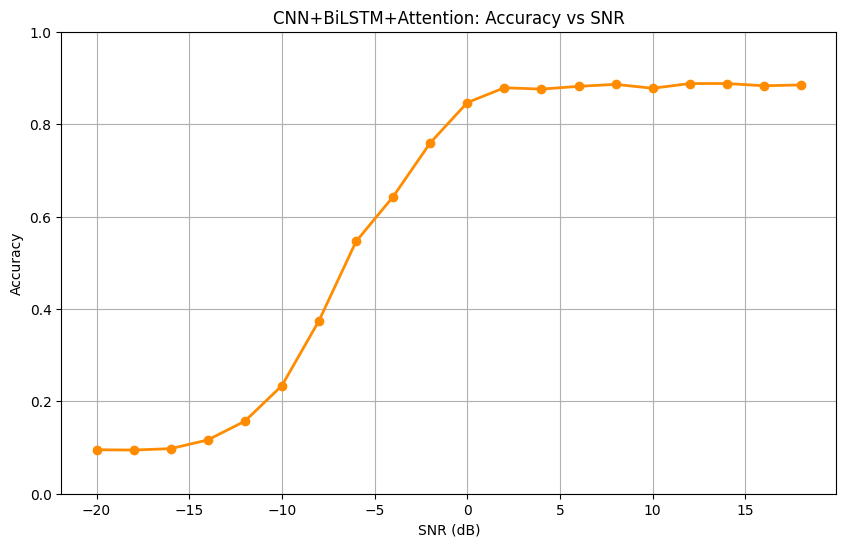

In [8]:
unique_snrs = sorted(np.unique(snr_test))
snr_accuracies_bilstm = []

for s in unique_snrs:
    mask = (snr_test == s)
    acc = (all_preds[mask] == all_labels[mask]).mean()
    snr_accuracies_bilstm.append(acc)
    print(f"SNR {s:>4} dB: Accuracy = {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(unique_snrs, snr_accuracies_bilstm, marker='o', linewidth=2, color='darkorange')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('CNN+BiLSTM+Attention: Accuracy vs SNR')
plt.grid(True)
plt.ylim(0, 1)
plt.savefig('../results/cnn_bilstm_attention_snr_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import json
results_bilstm={
    'unique_snrs': [int(s) for s in unique_snrs],
    'snr_accuracies': [float(a) for a in snr_accuracies_bilstm],
    'overall_test_acc': float(overall_test_acc)
}
with open('../results/bilstm_attention_results.json', 'w') as f:
    json.dump(results_bilstm, f, indent=2)
print("Saved BiLSTM+Attention results to disk")

Saved BiLSTM+Attention results to disk


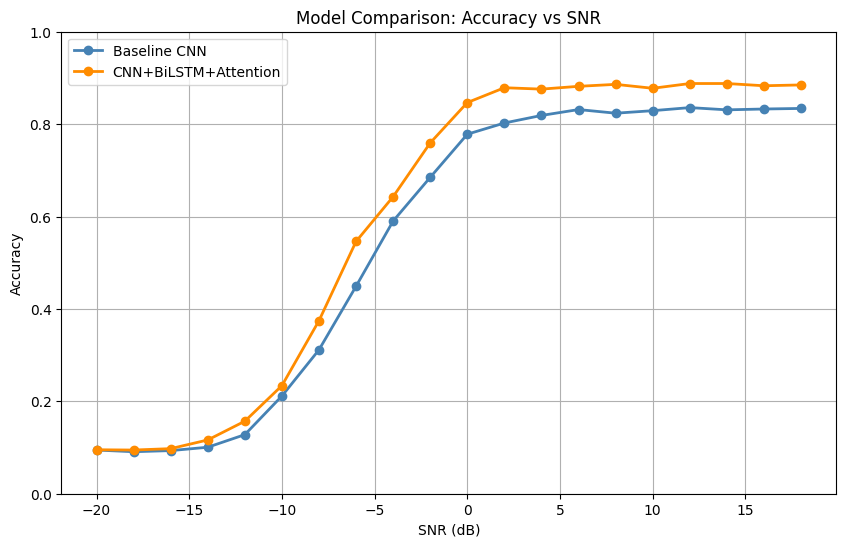

In [13]:
with open('../results/baseline_cnn_results.json', 'r') as f:
    results_baseline = json.load(f)
with open('../results/bilstm_attention_results.json', 'r') as f:
    results_bilstm = json.load(f)
plt.figure(figsize=(10, 6))
plt.plot(results_baseline['unique_snrs'],results_baseline['snr_accuracies'],marker='o',linewidth=2,label='Baseline CNN',color='steelblue')
plt.plot(results_bilstm['unique_snrs'],results_bilstm['snr_accuracies'],marker='o',linewidth=2,label='CNN+BiLSTM+Attention',color='darkorange')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Model Comparison: Accuracy vs SNR')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.savefig('../results/comparison_baseline_vs_bilstm.png', dpi=300, bbox_inches='tight')
plt.show()